# Seq2Seq Übersetzungsmodell, DPO Fine-Tuning & Evaluierung
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook kapselt das Training und die Evaluierung des Übersetzungsmodells:
1. **Phase 1: Supervised Fine-Tuning (SFT)** – Das Sequence-to-Sequence Basismodell wird auf parallelen Korpuspaaren vortrainiert.
2. **Phase 2 & 3: Direct Preference Optimization (DPO)** – Feinjustierung des Übersetzers mithilfe einer **Composite Reward-Funktion** bestehend aus:
   - **1. Stil & Einfachheits-Score ($R_{\text{style}}$):** Unser trainierter **BiLSTM Synthetic Regressor** (`bilstm_synthetic_regression.pt`), der den Zielgrad an Leichter Sprache $\lambda \in [0, 1]$ misst.
   - **2. Semantischer Erhalt ($R_{\text{sem}}$):** **SBERT / Jina Cosine Similarity**, welche die inhaltliche Übereinstimmung zwischen Quelltext $x_{\text{AS}}$ und Übersetzung $y'$ misst.
3. **Phase 4: Evaluierung auf dem unabhängigen Lebenshilfe-Datensatz** – Das trainierte Modell übersetzt den Out-of-Domain Datensatz (`data/lebenshilfe/lebenshilfe_dataset.json`) und wird bewertet.

In [1]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset.json"
OUTPUT_DIR = "results/models/seq2seq_dpo_translation_model"
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"

MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
MODEL_NAME = "facebook/mbart-large-50"


## 1. Setup & Importe

In [3]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

import os
print("Aktuelles Arbeitsverzeichnis von Python:", os.getcwd())
print("Existiert der data-Ordner hier?", os.path.exists("data"))
print("Existiert der data-Ordner eine Ebene höher?", os.path.exists("../data"))

CUDA verfügbar: True
Device Name: NVIDIA GeForce RTX 4090
Aktuelles Arbeitsverzeichnis von Python: /home/fiete/master-thesis
Existiert der data-Ordner hier? True
Existiert der data-Ordner eine Ebene höher? False


In [4]:
import os
import json
import glob
import random
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sentence_transformers import SentenceTransformer, util

print(torch.__version__)


# Device Configuration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Nutze Device: {DEVICE}")

2.6.0+cu124
Nutze Device: cuda


## 2. Datenladen & Korpus-Vorbereitung
Wir laden alle Korpusdaten aus `../../data/corpus/final/` für das SFT & DPO Training.

In [5]:
import os
import glob

# 1. Wo sind wir gerade?
print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

# 2. Was liegt in diesem Arbeitsverzeichnis?
print("Dateien hier:", os.listdir("."))

# 3. Teste verschiedene Pfade zu 'data/corpus/final'
pfade_zum_testen = [
    "data/corpus/final",
    "data/corpus/final",
    "data/corpus/final",
    "C:/Users/fiete/git/master/data/corpus/final" # Absoluter Pfad
]

for pfad in pfade_zum_testen:
    existiert = os.path.exists(pfad)
    anzahl_dateien = len(glob.glob(os.path.join(pfad, "*.json"))) if existiert else 0
    print(f"Pfad '{pfad}': Existiert = {existiert}, JSON-Dateien = {anzahl_dateien}")

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis
Dateien hier: ['requirements.txt', '.git', '.gitignore', 'results', 'scripts', 'docs', 'run_jupyter_server.md', 'data', '.venv', 'README.md', 'research', 'notebooks']
Pfad 'data/corpus/final': Existiert = True, JSON-Dateien = 12
Pfad 'data/corpus/final': Existiert = True, JSON-Dateien = 12
Pfad 'data/corpus/final': Existiert = True, JSON-Dateien = 12
Pfad 'C:/Users/fiete/git/master/data/corpus/final': Existiert = False, JSON-Dateien = 0


In [6]:
def load_corpus_pairs(corpus_dir="data/corpus/final"):
    pairs = []
    json_files = glob.glob(os.path.join(corpus_dir, "*.json"))
    print(f"{len(json_files)} Korpusdateien gefunden.")
    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            for item in data.get("pairs", []):
                as_text = item.get("as_text", "").strip()
                ls_text = item.get("ls_text", "").strip()
                if as_text and ls_text:
                    pairs.append({
                        "source": data.get("source", "unknown"),
                        "as_text": as_text,
                        "ls_text": ls_text
                    })
    return pairs

all_pairs = load_corpus_pairs()
print(f"Gesamtzahl geladener Artikel-Paare: {len(all_pairs)}")

# Split in Train (85%), Val (15%)
random.seed(42)
random.shuffle(all_pairs)
split_idx = int(0.85 * len(all_pairs))
train_data = all_pairs[:split_idx]
val_data = all_pairs[split_idx:]
print(f"Trainingsdaten: {len(train_data)} Paare | Validierungsdaten: {len(val_data)} Paare")

12 Korpusdateien gefunden.
Gesamtzahl geladener Artikel-Paare: 1471
Trainingsdaten: 1250 Paare | Validierungsdaten: 221 Paare


## 3. Phase 1: Supervised Fine-Tuning (SFT) Baseline

> **Hinweis zur Modellwahl:**
> - `google/mt5-small` (~1.2 GB, sehr schneller Download & Start)
> - `google/mt5-base` (~2.2 GB)
> - `facebook/mbart-large-50` (~2.44 GB, großes Modell mit vortrainierter deutscher Übersetzung)

In [7]:
# Optionen: "google/mt5-small", "google/mt5-base", "facebook/mbart-large-50"
# MODEL_NAME = "facebook/mbart-large-50"  # -> Zentral oben definiert
# MAX_SOURCE_LEN = 256  # -> Zentral oben definiert
# MAX_TARGET_LEN = 256  # -> Zentral oben definiert

print(f"Lade Tokenizer & Modell: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
seq2seq_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

if "mbart" in MODEL_NAME.lower():
    tokenizer.src_lang = "de_DE"
    tokenizer.tgt_lang = "de_DE"

print("Modell & Tokenizer erfolgreich geladen!")

Lade Tokenizer & Modell: facebook/mbart-large-50...


Loading weights:   0%|          | 0/519 [00:00<?, ?it/s]

Modell & Tokenizer erfolgreich geladen!


In [8]:
# seq2seq_model.load_state_dict(torch.load("results/models/best_sft_model_temp.pt"))
# print("Erfolgreich SFT-Modellgewichte von Festplatte geladen!")

In [9]:
class TranslationDataset(Dataset):
    def __init__(self, data, tokenizer, max_src_len=256, max_tgt_len=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        src_text = "Übersetze in Leichte Sprache: " + item["as_text"]
        tgt_text = item["ls_text"]
        
        inputs = self.tokenizer(
            src_text, max_length=self.max_src_len, padding="max_length", truncation=True, return_tensors="pt"
        )
        labels = self.tokenizer(
            tgt_text, max_length=self.max_tgt_len, padding="max_length", truncation=True, return_tensors="pt"
        )["input_ids"]
        
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": labels.squeeze(0),
            "raw_as": item["as_text"],
            "raw_ls": item["ls_text"]
        }

train_dataset = TranslationDataset(train_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)
val_dataset = TranslationDataset(val_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
print(f"DataLoader erstellt: {len(train_loader)} Batches (Train), {len(val_loader)} Batches (Val).")

DataLoader erstellt: 313 Batches (Train), 56 Batches (Val).


Starte SFT Training mit Validation und Early Stopping...

--- Epoche 1/20 ---


SFT Training:   0%|          | 0/313 [00:00<?, ?it/s]

SFT Validation:   0%|          | 0/56 [00:00<?, ?it/s]

Epoche 1 | Train Loss: 2.9605 | Val Loss: 2.3476
-> Neues bestes Modell gespeichert.

--- Epoche 2/20 ---


SFT Training:   0%|          | 0/313 [00:00<?, ?it/s]

...

SFT Validation:   0%|          | 0/56 [00:00<?, ?it/s]

Epoche 19 | Train Loss: 1.7022 | Val Loss: 14.0617

--- Epoche 20/20 ---


SFT Training:   0%|          | 0/313 [00:00<?, ?it/s]

SFT Validation:   0%|          | 0/56 [00:00<?, ?it/s]

Epoche 20 | Train Loss: 12.7743 | Val Loss: 11.1332
Early Stopping getriggert! Keine Verbesserung des Val Loss seit 5 Epochen.
Die besten SFT-Gewichte wurden erfolgreich geladen!


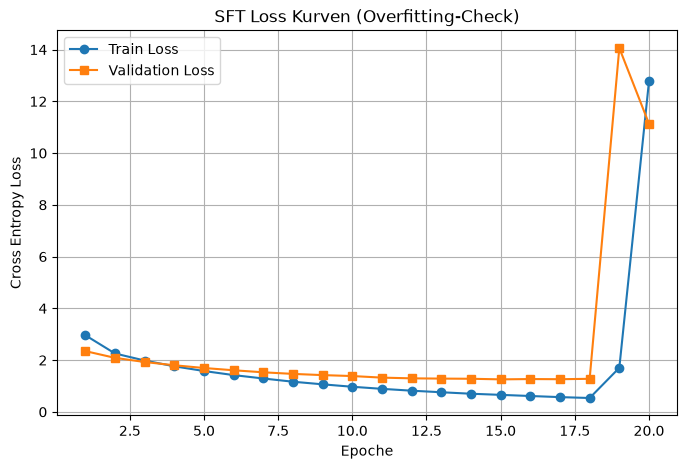

In [10]:
def train_sft_epoch(model, dataloader, optimizer, scheduler, accumulation_steps=4):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()  # Gradienten zu Beginn der Epoche nullen
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="SFT Training")):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        
        # Loss berechnen und durch die Anzahl der Akkumulationsschritte teilen
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss / accumulation_steps
        loss.backward()
        
        # Nur alle 'accumulation_steps' (4) Batches den Optimierungsschritt machen
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()  # Gradienten nach dem Schritt wieder zurücksetzen
            
        total_loss += loss.item() * accumulation_steps
        
    return total_loss / len(dataloader)

def validate_sft_epoch(model, dataloader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="SFT Validation"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                
            total_loss += outputs.loss.item()
            
    return total_loss / len(dataloader)

NUM_EPOCHS = 20
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": []}

optimizer = AdamW(seq2seq_model.parameters(), lr=1e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=150, 
    num_training_steps=len(train_loader) * NUM_EPOCHS
)

print("Starte SFT Training mit Validation und Early Stopping...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoche {epoch + 1}/{NUM_EPOCHS} ---")
    
    # Train und Val Losses berechnen
    sft_loss = train_sft_epoch(seq2seq_model, train_loader, optimizer, scheduler)
    val_loss = validate_sft_epoch(seq2seq_model, val_loader)
    
    history["train_loss"].append(sft_loss)
    history["val_loss"].append(val_loss)
    
    print(f"Epoche {epoch + 1} | Train Loss: {sft_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Early Stopping und Model Saving Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Bestes Modell zwischenspeichern
        torch.save(seq2seq_model.state_dict(), "results/models/best_sft_model_temp.pt")
        print("-> Neues bestes Modell gespeichert.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early Stopping getriggert! Keine Verbesserung des Val Loss seit {patience} Epochen.")
            # Lade beste Gewichte wieder
            seq2seq_model.load_state_dict(torch.load("results/models/best_sft_model_temp.pt"))
            break

if os.path.exists("results/models/best_sft_model_temp.pt"):
    seq2seq_model.load_state_dict(torch.load("results/models/best_sft_model_temp.pt"))
    print("Die besten SFT-Gewichte wurden erfolgreich geladen!")


# Visualisierung der SFT Loss-Kurven
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker='o', label='Train Loss')
plt.plot(range(1, len(history["val_loss"]) + 1), history["val_loss"], marker='s', label='Validation Loss')
plt.title("SFT Loss Kurven (Overfitting-Check)")
plt.xlabel("Epoche")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()


## 4. Phase 2: Composite Reward Function (Einfachheit + Semantikerhalt)
Fokus auf **1. (Synthetic Regressor) und 2. (SBERT Similarity)**:
$$R(x_{\text{AS}}, y') = w_{\text{style}} \cdot R_{\text{style}}(y') + w_{\text{sem}} \cdot R_{\text{sem}}(x_{\text{AS}}, y')$$

In [11]:
import os
print("Aktuelles Arbeitsverzeichnis des Notebooks:", os.getcwd())
print("Existiert der Ordner 'results'?", os.path.exists("./results"))
print("Inhalt von 'results':", os.listdir("./results") if os.path.exists("./results") else "Ordner nicht da")

Aktuelles Arbeitsverzeichnis des Notebooks: /home/fiete/master-thesis
Existiert der Ordner 'results'? True
Inhalt von 'results': ['reports', 'plots', 'models']


In [13]:
# 4.1 BiLSTM Regressor & Vocab laden
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"  # -> Zentral oben definiert
# SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"  # -> Zentral oben definiert

with open(SYNTHETIC_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    synthetic_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(synthetic_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(SYNTHETIC_MODEL_PATH):
    bilstm_model.load_state_dict(torch.load(SYNTHETIC_MODEL_PATH, map_location="cpu"))
    bilstm_model.to("cpu")
    bilstm_model.eval()
    print(f"BiLSTM Synthetic Regressor erfolgreich geladen von {SYNTHETIC_MODEL_PATH}")
else:
    print(f"Warnung: {SYNTHETIC_MODEL_PATH} nicht gefunden.")

nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def predict_simplicity_score(texts):
    scores = []
    unk_idx = synthetic_stoi.get("<unk>") or synthetic_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(text)
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [synthetic_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        # FIX: Invertiere Komplexität (0.0 = AS, 1.0 = LS)
        scores.append(1.0 - score)
    return np.array(scores)

BiLSTM Synthetic Regressor erfolgreich geladen von results/models/bilstm_synthetic_regression.pt


In [14]:
# 4.2 SBERT Semantic Similarity Model laden
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [15]:
# 4.3 Composite Reward Evaluator
class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts) # [0, 1]
        r_sem = predict_semantic_similarity(source_texts, generated_texts) # [-1, 1]
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=0.5, w_sem=0.5)

## 5. Phase 3: Direct Preference Optimization (DPO)
Wir erzeugen Kandidaten, bewerten sie mit $R(x, y')$ und optimieren das Modell mit DPO Loss.

In [16]:
def generate_candidates(model, tokenizer, source_texts, num_return_sequences=2):
    model.eval()
    prompt_texts = ["Übersetze in Leichte Sprache: " + text for text in source_texts]
    inputs = tokenizer(prompt_texts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=MAX_TARGET_LEN,
            do_sample=True,             # Wichtig für mehrere Sequenzen!
            top_k=50,
            top_p=0.92,
            temperature=0.8,
            num_return_sequences=num_return_sequences
        )
        
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    
    # Sicherstellen, dass wir genau B * N Sequenzen haben
    expected_len = len(source_texts) * num_return_sequences
    if len(decoded) < expected_len:
        print(f"Warnung: Generierte Sequenzen ({len(decoded)}) weichen von Erwartung ({expected_len}) ab!")
        # Auffüllen mit leeren Strings, um IndexError zu verhindern
        decoded += [""] * (expected_len - len(decoded))
        
    candidates = []
    for i in range(len(source_texts)):
        cands = decoded[i * num_return_sequences : (i + 1) * num_return_sequences]
        # Absicherung: Falls cands unvollständig ist
        while len(cands) < num_return_sequences:
            cands.append("")
        candidates.append(cands)
    return candidates

def compute_dpo_loss(model, ref_model, tokenizer, src_texts, chosen_texts, rejected_texts, beta=0.1):
    model.train()
    ref_model.eval()
    
    prompts = ["Übersetze in Leichte Sprache: " + t for t in src_texts]
    inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
    chosen_enc = tokenizer(chosen_texts, padding=True, truncation=True, max_length=MAX_TARGET_LEN, return_tensors="pt").to(DEVICE)
    rejected_enc = tokenizer(rejected_texts, padding=True, truncation=True, max_length=MAX_TARGET_LEN, return_tensors="pt").to(DEVICE)
    
    # Nutze Autocast (bfloat16 oder float16) zur Speicherersparnis
    # Falls deine Grafikkarte älter ist und kein bfloat16 unterstützt, nimm torch.float16
    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
        # 1. Referenzmodell-Werte berechnen und direkt als Float extrahieren
        with torch.no_grad():
            ref_chosen_loss = ref_model(
                input_ids=inputs["input_ids"], 
                attention_mask=inputs["attention_mask"], 
                labels=chosen_enc["input_ids"]
            ).loss.item()
            
            ref_rejected_loss = ref_model(
                input_ids=inputs["input_ids"], 
                attention_mask=inputs["attention_mask"], 
                labels=rejected_enc["input_ids"]
            ).loss.item()
            
        ref_logratios = -ref_chosen_loss + ref_rejected_loss
        
        # 2. Policy-Modell (aktives Modell) berechnen
        out_chosen = model(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"], 
            labels=chosen_enc["input_ids"]
        )
        pi_chosen_loss = out_chosen.loss
        
        out_rejected = model(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"], 
            labels=rejected_enc["input_ids"]
        )
        pi_rejected_loss = out_rejected.loss
        
        pi_logratios = -pi_chosen_loss + pi_rejected_loss
        
        # 3. DPO-Loss berechnen
        logits = pi_logratios - ref_logratios
        dpo_loss = -torch.nn.functional.logsigmoid(beta * logits).mean()
        
    return dpo_loss


import copy
import gc
import torch

# Lösche den alten SFT-Optimierer, Scheduler und Loader
if 'optimizer' in globals():
    del optimizer
if 'scheduler' in globals():
    del scheduler
if 'train_loader' in globals():
    del train_loader
if 'val_loader' in globals():
    del val_loader

# Garbage Collector ausführen und PyTorch-Speicher freigeben
gc.collect()
torch.cuda.empty_cache()
ref_model = copy.deepcopy(seq2seq_model).to(DEVICE)
for param in ref_model.parameters():
    param.requires_grad = False
ref_model.eval()

dpo_optimizer = AdamW(seq2seq_model.parameters(), lr=1e-6)

Starte DPO Training...


DPO Epoch 1/2:   0%|          | 0/313 [00:00<?, ?it/s]


--- DPO Epoche 1 Ergebnisse ---
Ø DPO Loss:       0.6929
Ø Style Reward:    0.8648
Ø Semantic Reward: 0.8645



DPO Epoch 2/2:   0%|          | 0/313 [00:00<?, ?it/s]


--- DPO Epoche 2 Ergebnisse ---
Ø DPO Loss:       0.6931
Ø Style Reward:    0.8510
Ø Semantic Reward: 0.8691



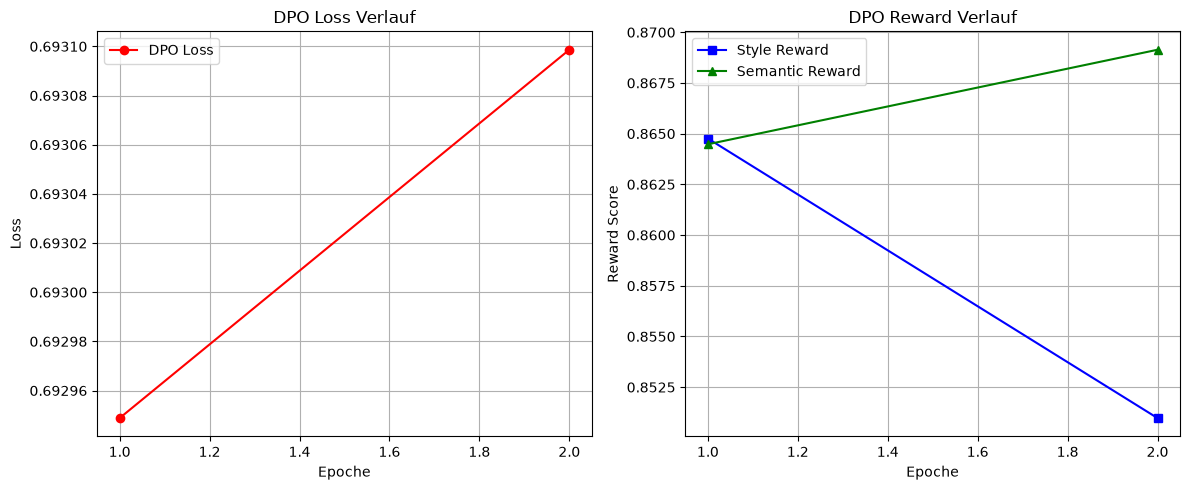

In [17]:
DPO_EPOCHS = 2
dpo_history = []

print("Starte DPO Training...")
for epoch in range(1, DPO_EPOCHS + 1):
    epoch_dpo_loss = 0.0
    epoch_style_rewards = []
    epoch_sem_rewards = []
    
    # Subset der Trainingsdaten für DPO, um das Generieren von Kandidaten zu beschleunigen
    dpo_loader = DataLoader(
        TranslationDataset(train_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN), 
        batch_size=4, 
        shuffle=True
    )
    
    for batch in tqdm(dpo_loader, desc=f"DPO Epoch {epoch}/{DPO_EPOCHS}"):
        src_texts = batch["raw_as"]
        
        # 1. Kandidaten generieren
        candidates = generate_candidates(seq2seq_model, tokenizer, src_texts, num_return_sequences=2)
        
        chosen_list = []
        rejected_list = []
        
        # 2. Pairwise Rewards bestimmen
        for src, cands in zip(src_texts, candidates):
            r1, st1, sem1 = reward_evaluator.compute_reward([src], [cands[0]])
            r2, st2, sem2 = reward_evaluator.compute_reward([src], [cands[1]])
            
            if r1[0] >= r2[0]:
                chosen_list.append(cands[0])
                rejected_list.append(cands[1])
                epoch_style_rewards.append(st1[0])
                epoch_sem_rewards.append(sem1[0])
            else:
                chosen_list.append(cands[1])
                rejected_list.append(cands[0])
                epoch_style_rewards.append(st2[0])
                epoch_sem_rewards.append(sem2[0])
                
        # 3. DPO Loss berechnen & Optimieren
        dpo_loss = compute_dpo_loss(seq2seq_model, ref_model, tokenizer, src_texts, chosen_list, rejected_list)
        dpo_optimizer.zero_grad()
        dpo_loss.backward()
        dpo_optimizer.step()
        
        epoch_dpo_loss += dpo_loss.item()
        
    # Protokollierung der Epochen-Ergebnisse
    avg_loss = epoch_dpo_loss / len(dpo_loader)
    avg_style = np.mean(epoch_style_rewards)
    avg_sem = np.mean(epoch_sem_rewards)
    
    dpo_history.append({
        "epoch": epoch,
        "loss": avg_loss,
        "style_reward": avg_style,
        "sem_reward": avg_sem
    })
    
    print(f"\n--- DPO Epoche {epoch} Ergebnisse ---")
    print(f"Ø DPO Loss:       {avg_loss:.4f}")
    print(f"Ø Style Reward:    {avg_style:.4f}")
    print(f"Ø Semantic Reward: {avg_sem:.4f}\n")

# Visualisierung des DPO Trainingsverlaufs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs = [h["epoch"] for h in dpo_history]
losses = [h["loss"] for h in dpo_history]
style_rewards = [h["style_reward"] for h in dpo_history]
sem_rewards = [h["sem_reward"] for h in dpo_history]

ax1.plot(epochs, losses, marker='o', color='red', label='DPO Loss')
ax1.set_title("DPO Loss Verlauf")
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, style_rewards, marker='s', color='blue', label='Style Reward')
ax2.plot(epochs, sem_rewards, marker='^', color='green', label='Semantic Reward')
ax2.set_title("DPO Reward Verlauf")
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Reward Score")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## 6. Modell Speichern
Speichern des trainierten Modells unter `../../results/models/seq2seq_dpo_translation_model/`.

In [18]:
# OUTPUT_DIR = "results/models/seq2seq_dpo_translation_model"  # -> Zentral oben definiert
os.makedirs(OUTPUT_DIR, exist_ok=True)

seq2seq_model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Modell und Tokenizer erfolgreich gespeichert unter: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modell und Tokenizer erfolgreich gespeichert unter: results/models/seq2seq_dpo_translation_model


## 7. Evaluierung auf dem unabhängigen Lebenshilfe-Datensatz (Out-of-Domain Test)
Das trainierte Modell übersetzt nun den unabhängigen Lebenshilfe-Datensatz (`data/lebenshilfe/lebenshilfe_dataset.json`). Wir berechnen:
1. **Synthetic-Einfachheits-Score ($R_{\text{style}}$)**
2. **SBERT-Ähnlichkeit zur AS-Quelle ($R_{\text{sem}}$)**
3. **SBERT-Ähnlichkeit zum echten menschlichen LS-Referenztext**
4. **Gesamt-Reward**

In [19]:
# 7.1 Lebenshilfe-Datensatz laden
# LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset.json"  # -> Zentral oben definiert
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

Lebenshilfe Datensatz geladen: 49 Artikel-Paare.


In [20]:
# 7.2 Übersetzen & Metriken berechnen
def evaluate_on_lebenshilfe(model, tokenizer, lh_data, reward_evaluator, max_samples=49):
    model.eval()
    as_texts = [item["as_text"] for item in lh_data[:max_samples]]
    ls_ref_texts = [item["ls_text"] for item in lh_data[:max_samples]]
    
    batch_size = 16
    gen_texts = []
    for i in tqdm(range(0, len(as_texts), batch_size), desc="Übersetze Lebenshilfe Datensatz"):
        batch_src = as_texts[i:i+batch_size]
        prompts = ["Übersetze in Leichte Sprache: " + t for t in batch_src]
        inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
                outputs = model.generate(
                    input_ids=inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    max_length=MAX_TARGET_LEN,
                    num_beams=4,                 # Erhöht die Suchtiefe
                    repetition_penalty=2.5,      # Bestraft wiederholte Tokens hart
                    no_repeat_ngram_size=3,      # Verbietet Wiederholung von 3er-Wortfolgen
                    early_stopping=True
                )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    tot_reward, r_style, r_sem = reward_evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "model_translation": gen_texts,
        "synthetic_simplicity_score": r_style,
        "sbert_sim_to_as": r_sem,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward
    })
    
    print("\n=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
    print(f"Ø Synthetic-Einfachheits-Score (R_style):       {r_style.mean():.4f} ± {r_style.std():.4f}")
    print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle (R_sem):   {r_sem.mean():.4f} ± {r_sem.std():.4f}")
    print(f"Ø SBERT-Ähnlichkeit zu echter LS-Referenz:  {sim_to_ref_norm.mean():.4f} ± {sim_to_ref_norm.std():.4f}")
    print(f"Ø Composite Reward:                        {tot_reward.mean():.4f} ± {tot_reward.std():.4f}")
    print("========================================================================\n")
    
    return df_res

lh_eval_df = evaluate_on_lebenshilfe(seq2seq_model, tokenizer, lh_data, reward_evaluator)

Übersetze Lebenshilfe Datensatz:   0%|          | 0/4 [00:00<?, ?it/s]


=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Synthetic-Einfachheits-Score (R_style):       0.8865 ± 0.2079
Ø SBERT-Ähnlichkeit zur AS-Quelle (R_sem):   0.8626 ± 0.0612
Ø SBERT-Ähnlichkeit zu echter LS-Referenz:  0.8336 ± 0.0770
Ø Composite Reward:                        0.8746 ± 0.1085



In [21]:
# 7.3 Statistische Übersicht & Qualitatives Stichproben-Audit
display(lh_eval_df[["synthetic_simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]].describe())

print("\n--- QUALITATIVE STICHPROBEN (LEBENSHILFE TESTSET) ---")
for idx, row in lh_eval_df.head(3).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:     {row['as_text'][:130]}...")
    print(f"LS-Referenz:   {row['ls_reference'][:130]}...")
    print(f"Modell-Übers.: {row['model_translation']}")
    print(f"Scores: Style={row['synthetic_simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f}")

,synthetic_simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,49.000000,49.000000,49.000000,49.000000
mean,0.886534,0.862582,0.833628,0.874558
std,0.210035,0.061802,0.077819,0.109599
min,0.042825,0.667455,0.573280,0.355140
25%,0.910296,0.832910,0.792955,0.869134
50%,0.965655,0.861576,0.852039,0.910579
75%,0.985169,0.903779,0.887129,0.921803
max,0.990726,0.977764,0.947005,0.965017



--- QUALITATIVE STICHPROBEN (LEBENSHILFE TESTSET) ---

[Artikel 1]
AS-Quelle:     Presseinformation von CAU und StK
3.12.2024
xxx/2024
„Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen

Ministerprä...
LS-Referenz:   Das Geologische und Mineralogische Museum in Leichter Sprache

Einführung
An der Universität Kiel arbeiten sehr viele Wissenschaft...
Modell-Übers.: Was ist Inklusion? Daniel Günther und die Landesregierung machen einen Film zum Thema „Inklusion im Fokus“ Am 3. Dezember vom Jahr 2024 gab es an der Christian-Albrechts-Universität zu Kiel einen Aktionstag. Dieser Tag ist ein besonderer Tag. An dem Tag wollen Menschen mit Behinderung zusammen mit anderen Menschen über wichtige Themen sprechen. Den Aktionstag haben die Bundes-Regierung und die CAU gemacht. Dabei ging es um den Film: „Das ist Leben - einzigartig vielfältig“. Der Film soll anschaulich über das Thema Teilhabe in Deutschland und der Welt erzählen. Daniel G
Scores: Style=0.950 | Sim(AS)=0.928 | Sim(R

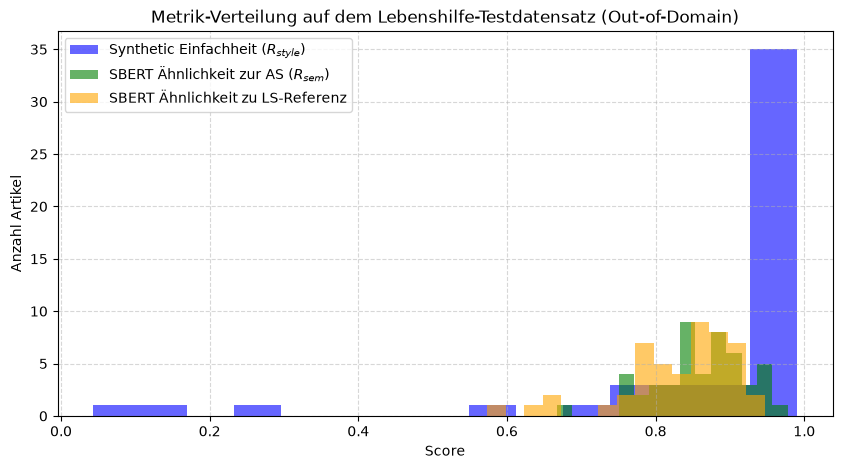

In [22]:
# 7.4 Visualisierung der Metrik-Verteilungen auf dem Lebenshilfe-Set
plt.figure(figsize=(10, 5))
plt.hist(lh_eval_df["synthetic_simplicity_score"], bins=15, alpha=0.6, label="Synthetic Einfachheit ($R_{style}$)", color="blue")
plt.hist(lh_eval_df["sbert_sim_to_as"], bins=15, alpha=0.6, label="SBERT Ähnlichkeit zur AS ($R_{sem}$)", color="green")
plt.hist(lh_eval_df["sbert_sim_to_ref"], bins=15, alpha=0.6, label="SBERT Ähnlichkeit zu LS-Referenz", color="orange")
plt.title("Metrik-Verteilung auf dem Lebenshilfe-Testdatensatz (Out-of-Domain)")
plt.xlabel("Score")
plt.ylabel("Anzahl Artikel")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()